# Adult Income ANN Project

The main objective of this project is to build an Artificial Neural Network, or ANN, that predicts whether a person's annual income is less than or equal to 50 thousand dollars, or greater than 50 thousand dollars. 


This notebook follows the project tasks shown in the provided assignment:
1. Data Loading, Cleaning & EDA
2. Baseline ANN
3. Activation Function Comparison
4. Weight Initialization
5. Loss Function Comparison
6. Batch Normalization
7. Optimizer Comparison and Final ANN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

import tensorflow as tf
from tensorflow import keras

# Import train test split
from sklearn.model_selection import train_test_split

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve
)

# Display TensorFlow version
print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.21.0
Keras Version: 3.15.1


# Download the Dataset (Kaggle)

In [2]:
# Download the latest version of the dataset
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

# Print the download path
print("Dataset Path:", path)

Dataset Path: C:\Users\Santosh verma\.cache\kagglehub\datasets\wenruliu\adult-income-dataset\versions\2


## Find the CSV File

In [3]:
# List all files in the downloaded folder
os.listdir(path)

['adult.csv']

In [4]:
# Create the full file path
file_path = os.path.join(path, "adult.csv")

# Load the dataset
df = pd.read_csv(file_path)

In [5]:
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [6]:
print("Shape :", df.shape)

Shape : (48842, 15)


In [7]:
print(df.dtypes)

age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [9]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

In [10]:
# Remove extra spaces from object columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

C:\Users\Santosh verma\AppData\Local\Temp\ipykernel_3028\2284108036.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [11]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


# 1.2 Handle Missing Values

## Check missing value

In [12]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [13]:
# Replace ? with NaN
df = df.replace("?", np.nan)

## Missing values before dropping

In [14]:
print(df.isnull().sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


## Drop rows containing missing values

In [15]:
df = df.dropna()

## Reset index

In [16]:
df = df.reset_index(drop=True)

## Shape after removing missing values

In [17]:
print(df.shape)

(45222, 15)


## Missing values after cleaning:

In [18]:
print(df.isnull().sum())

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [19]:
df.shape

(45222, 15)

# 1.3 Drop redundant columns

In [20]:
df = df.drop(columns=["fnlwgt", "education"])

In [21]:
print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (45222, 13)


In [22]:
# Display columns
print("\nRemaining columns:")
print(df.columns.tolist())


Remaining columns:
['age', 'workclass', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


# 1.4 Encode Target Variable

In [23]:
df["income"] = (df["income"] == ">50K").astype(int)

## Display target distribution

In [24]:
print(df["income"].value_counts())

income
0    34014
1    11208
Name: count, dtype: int64


## Display target percentages

In [25]:
print(df["income"].value_counts(normalize=True) * 100)

income
0    75.215603
1    24.784397
Name: proportion, dtype: float64


# Plot target distribution

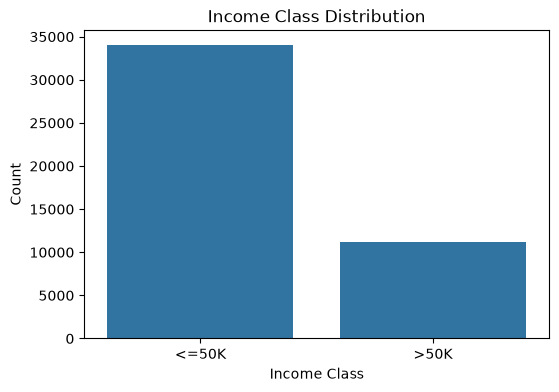

In [26]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="income")

plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")

plt.xticks([0, 1], ["<=50K", ">50K"])

plt.show()

# 1.5 Exploratory Data Analysis

## Plot age distribution

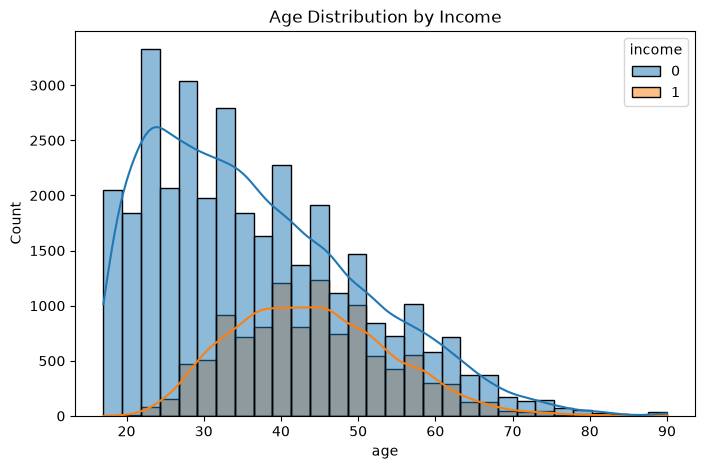

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="income",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Income")
plt.show()

## Plot hours per week

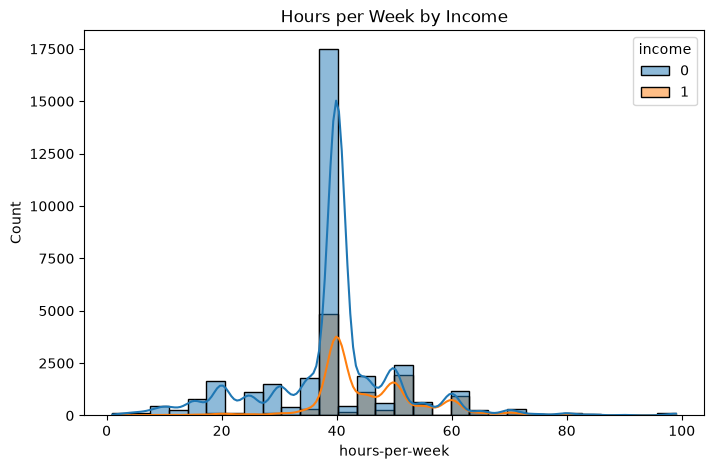

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="hours-per-week",
    hue="income",
    bins=30,
    kde=True
)

plt.title("Hours per Week by Income")
plt.show()

## Plot education number


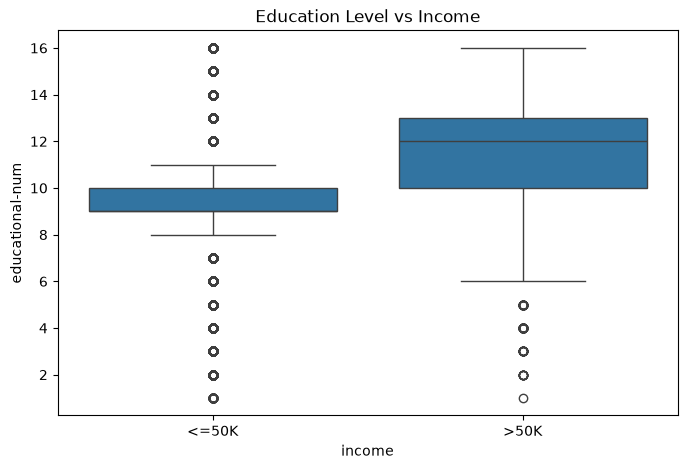

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="income",
    y="educational-num"
)

plt.title("Education Level vs Income")
plt.xticks([0, 1], ["<=50K", ">50K"])

plt.show()

## Plot correlation matrix

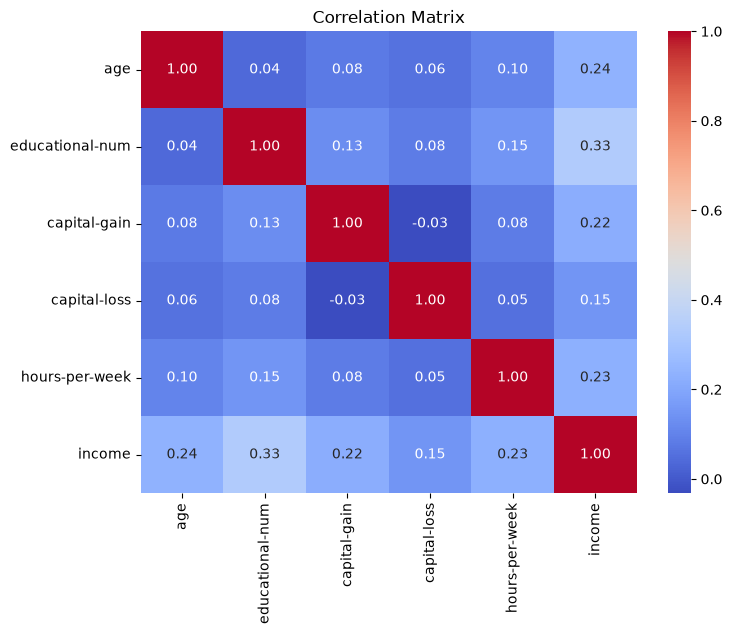

In [30]:
# Select numerical columns
numeric_columns = [
    "age",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "income"
]

# Calculate correlation
correlation = df[numeric_columns].corr()

# Plot correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# 1.6 Encode Categorical Variables and Scale Numerical Variables

In [31]:
# Separate input and target
X = df.drop(columns=["income"])
y = df["income"]

# One-hot encode categorical columns
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=float
)

# Display shape
print("X shape after One-Hot Encoding:", X.shape)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Numerical columns that need scaling
numeric_columns = [
    "age",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Scale numerical columns
scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

# Convert to numpy arrays
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")



X shape after One-Hot Encoding: (45222, 80)


## Display shapes

In [32]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Check class ratio
print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True))

X_train: (36177, 80)
X_test : (9045, 80)
y_train: (36177,)
y_test : (9045,)

Training Class Distribution:
income
0.0    0.752163
1.0    0.247837
Name: proportion, dtype: float64

Testing Class Distribution:
income
0.0    0.752128
1.0    0.247872
Name: proportion, dtype: float64


# 2: BASELINE ANN
## 2.1 Reusable build_ann() Function

In [33]:
# Create reusable ANN function
def build_ann(
    input_dim,
    hidden_units=[128, 64],
    activation="relu",
    initializer="glorot_uniform",
    use_batch_norm=False,
    optimizer="adam",
    loss="binary_crossentropy"
):

    # Create Sequential model
    model = keras.Sequential()

    # Input layer
    model.add(
        keras.layers.Input(shape=(input_dim,))
    )

    # First hidden layer
    model.add(
        keras.layers.Dense(
            hidden_units[0],
            activation=activation,
            kernel_initializer=initializer
        )
    )

    # Batch Normalization if required
    model.layers[-1]

    # Second hidden layer
    model.add(
        keras.layers.Dense(
            hidden_units[1],
            activation=activation,
            kernel_initializer=initializer
        )
    )

    # Output layer
    model.add(
        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )

    # Return model
    return model

## 2.2 Baseline ANN Architecture

In [34]:
# Create baseline model
model_base = build_ann(
    input_dim=X_train.shape[1],
    hidden_units=[128, 64],
    activation="relu",
    initializer="glorot_uniform",
    use_batch_norm=False,
    optimizer="adam",
    loss="binary_crossentropy"
)

model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

## 2.3 Train Baseline ANN

In [35]:
# Train baseline model
history_base = model_base.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8399 - loss: 0.3389 - val_accuracy: 0.8367 - val_loss: 0.3442
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8523 - loss: 0.3147 - val_accuracy: 0.8524 - val_loss: 0.3199
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3116 - val_accuracy: 0.8477 - val_loss: 0.3258
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8557 - loss: 0.3077 - val_accuracy: 0.8530 - val_loss: 0.3218
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8568 - loss: 0.3061 - val_accuracy: 0.8546 - val_loss: 0.3205
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8569 - loss: 0.3035 - val_accuracy: 0.8516 - val_loss: 0.3204
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8603 - loss: 0.3002 - val_accuracy: 0.8516 - val_loss: 0.3219
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8620 - loss: 0.2980 - val_accuracy: 0.

## Plot Training Curve

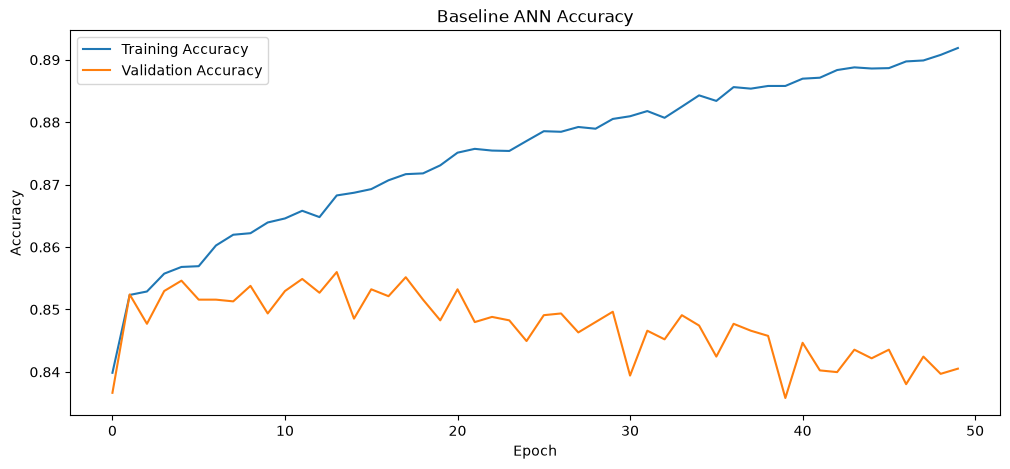

In [36]:
# Create figure
plt.figure(figsize=(12, 5))

# Plot training accuracy
plt.plot(
    history_base.history["accuracy"],
    label="Training Accuracy"
)

# Plot validation accuracy
plt.plot(
    history_base.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Plot Loss

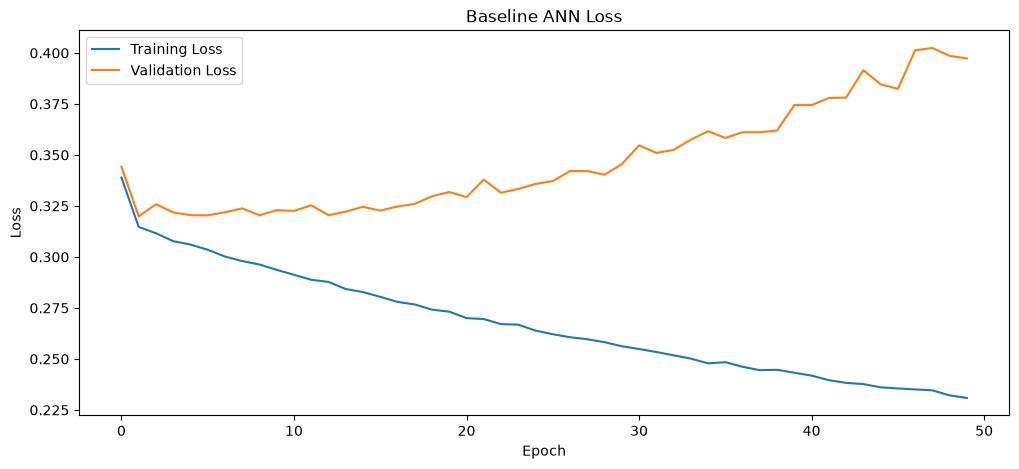

In [37]:
# Create figure
plt.figure(figsize=(12, 5))

# Plot training loss
plt.plot(
    history_base.history["loss"],
    label="Training Loss"
)

# Plot validation loss
plt.plot(
    history_base.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 2.4 Evaluate Baseline Model

In [38]:
# Predict probabilities
y_pred_prob = model_base.predict(X_test).flatten()

# Convert probability into class
y_pred = (y_pred_prob >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred,pos_label=1)
recall = recall_score(y_test,y_pred,pos_label=1)
f1 = f1_score(y_test,y_pred,pos_label=1)
pr_auc = average_precision_score(y_test,y_pred_prob)
roc_auc = roc_auc_score(y_test,y_pred_prob)

# Print results
print("Baseline ANN Results")
print("--------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("PR-AUC   :", pr_auc)
print("ROC-AUC  :", roc_auc)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Baseline ANN Results
--------------------
Accuracy : 0.8399115533443892
Precision: 0.6977091633466136
Recall   : 0.6248884924174843
F1 Score : 0.6592941176470588
PR-AUC   : 0.7457421299150924
ROC-AUC  : 0.8893491392722658


## Classification Report

In [39]:
# Print classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"]
    )
)

              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.90      6803
        >50K       0.70      0.62      0.66      2242

    accuracy                           0.84      9045
   macro avg       0.79      0.77      0.78      9045
weighted avg       0.84      0.84      0.84      9045



## Confusion Matrix

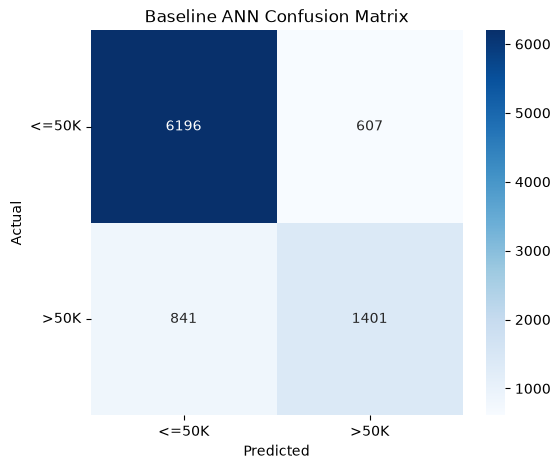

In [40]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Baseline ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(
    [0.5, 1.5],
    ["<=50K", ">50K"])

plt.yticks(
    [0.5, 1.5],
    ["<=50K", ">50K"],rotation=0)

plt.show()

## Precision-Recall Curve

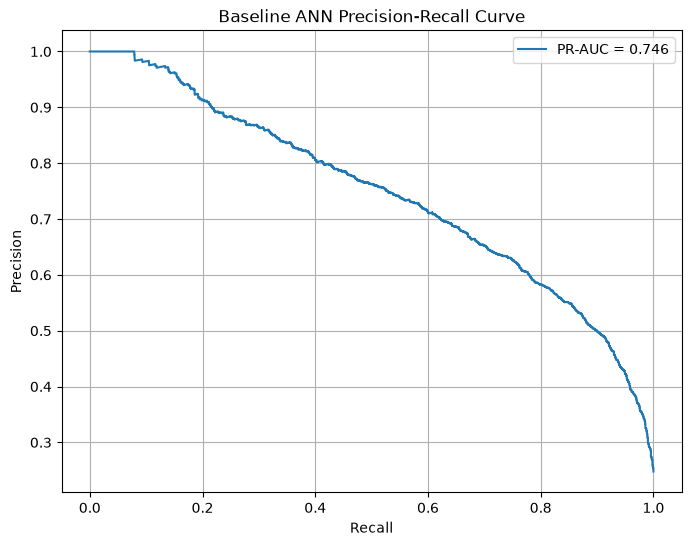

In [41]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_pred_prob
)

# Plot PR curve
plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Baseline ANN Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

# 2.5 Why ANN for Tabular Data?
## Why Tabular Data Suits ANN

The Adult Income dataset contains numerical and categorical features.

After preprocessing, categorical variables are converted into numerical one-hot encoded features. The resulting feature vector is suitable as input to a fully connected Multi-Layer Perceptron.

An ANN can learn weighted combinations and non-linear relationships between features such as age, education, occupation, hours worked and capital gain.

CNNs are mainly designed for spatial data such as images, while RNNs are mainly designed for sequential data. Therefore, a fully connected MLP is a suitable neural network architecture for this tabular classification problem.

# 3: ACTIVATION FUNCTIONS

We compare:

* ReLU
* Tanh
* Sigmoid
* ELU
## 3.1 Train Four Models

In [43]:
# Build ReLU model
model_relu = build_ann(
    X_train.shape[1],
    activation="relu"
)

# Train ReLU model
history_relu = model_relu.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8440 - loss: 0.3361 - val_accuracy: 0.8491 - val_loss: 0.3248
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3141 - val_accuracy: 0.8496 - val_loss: 0.3244
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8553 - loss: 0.3107 - val_accuracy: 0.8521 - val_loss: 0.3203
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8559 - loss: 0.3079 - val_accuracy: 0.8519 - val_loss: 0.3194
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8582 - loss: 0.3049 - val_accuracy: 0.8433 - val_loss: 0.3250
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8588 - loss: 0.3024 - val_accuracy: 0.8541 - val_loss: 0.3223
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8609 - loss: 0.2999 - val_accuracy: 0.8510 - val_loss: 0.3230
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8623 - loss: 0.2972 - val_accuracy: 0.

In [44]:
# Build Tanh model
model_tanh = build_ann(
    X_train.shape[1],
    activation="tanh"
)

# Train Tanh model
history_tanh = model_tanh.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)


Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8426 - loss: 0.3355 - val_accuracy: 0.8502 - val_loss: 0.3280
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8494 - loss: 0.3218 - val_accuracy: 0.8505 - val_loss: 0.3251
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8514 - loss: 0.3173 - val_accuracy: 0.8543 - val_loss: 0.3220
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8520 - loss: 0.3138 - val_accuracy: 0.8474 - val_loss: 0.3248
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8535 - loss: 0.3116 - val_accuracy: 0.8527 - val_loss: 0.3196
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8540 - loss: 0.3092 - val_accuracy: 0.8554 - val_loss: 0.3202
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8555 - loss: 0.3072 - val_accuracy: 0.8530 - val_loss: 0.3248
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8574 - loss: 0.3056 - val_accuracy: 0.

In [45]:
# Build Sigmoid model
model_sigmoid = build_ann(
    X_train.shape[1],
    activation="sigmoid"
)

# Train Sigmoid model
history_sigmoid = model_sigmoid.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)


Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8211 - loss: 0.3784 - val_accuracy: 0.8472 - val_loss: 0.3340
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8470 - loss: 0.3294 - val_accuracy: 0.8488 - val_loss: 0.3307
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8480 - loss: 0.3269 - val_accuracy: 0.8496 - val_loss: 0.3299
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8470 - loss: 0.3259 - val_accuracy: 0.8488 - val_loss: 0.3298
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8484 - loss: 0.3250 - val_accuracy: 0.8513 - val_loss: 0.3279
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8494 - loss: 0.3230 - val_accuracy: 0.8505 - val_loss: 0.3273
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8487 - loss: 0.3225 - val_accuracy: 0.8510 - val_loss: 0.3255
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8481 - loss: 0.3210 - val_accuracy: 0.

In [46]:
# Build ELU model
model_elu = build_ann(
    X_train.shape[1],
    activation="elu"
)

# Train ELU model
history_elu = model_elu.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8404 - loss: 0.3399 - val_accuracy: 0.8466 - val_loss: 0.3269
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8493 - loss: 0.3209 - val_accuracy: 0.8527 - val_loss: 0.3216
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.3174 - val_accuracy: 0.8521 - val_loss: 0.3199
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3155 - val_accuracy: 0.8535 - val_loss: 0.3219
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8528 - loss: 0.3144 - val_accuracy: 0.8549 - val_loss: 0.3223
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.3133 - val_accuracy: 0.8521 - val_loss: 0.3193
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8537 - loss: 0.3127 - val_accuracy: 0.8535 - val_loss: 0.3205
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8537 - loss: 0.3104 - val_accuracy: 0.

## 3.2 Activation Comparison Plot

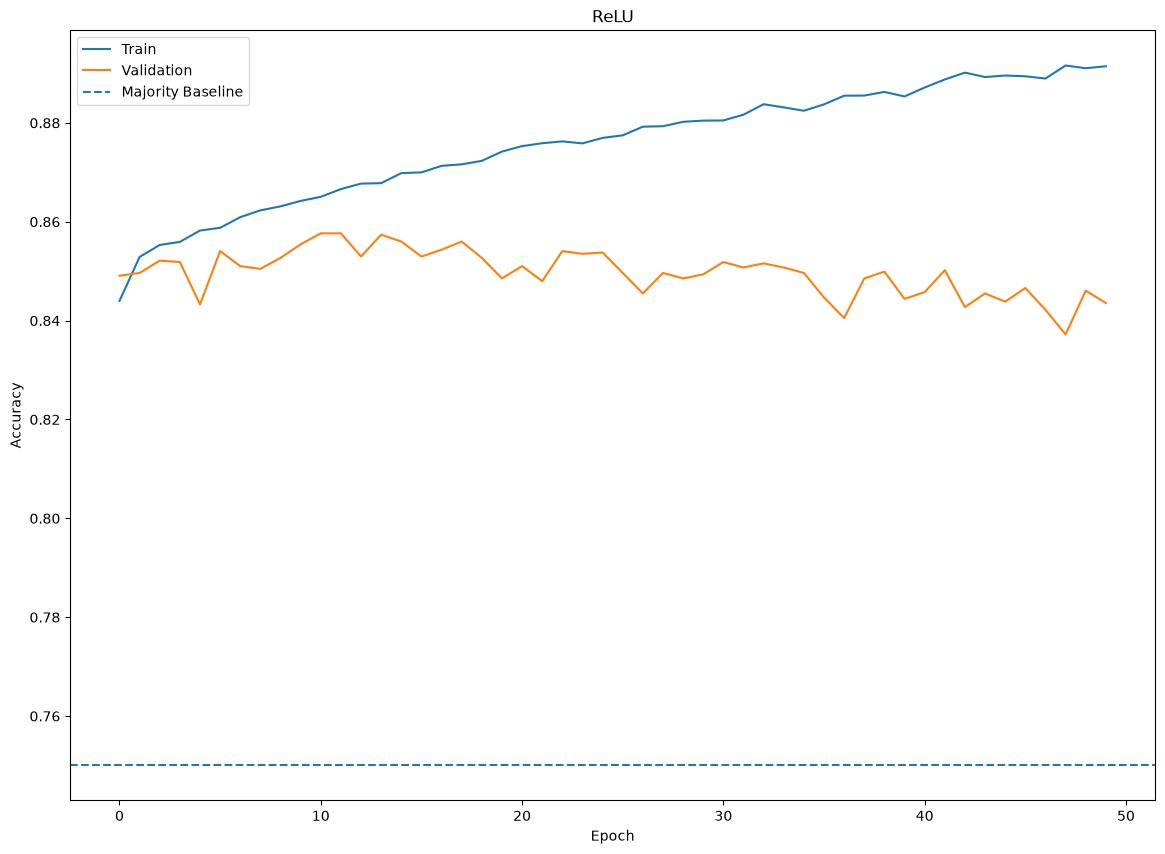

In [49]:
plt.figure(figsize=(14, 10))

plt.plot(
    history_relu.history["accuracy"],
    label="Train"
)

plt.plot(
    history_relu.history["val_accuracy"],
    label="Validation"
)

plt.title("ReLU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.axhline(
    y=0.75,
    linestyle="--",
    label="Majority Baseline"
)
plt.legend()
plt.show()

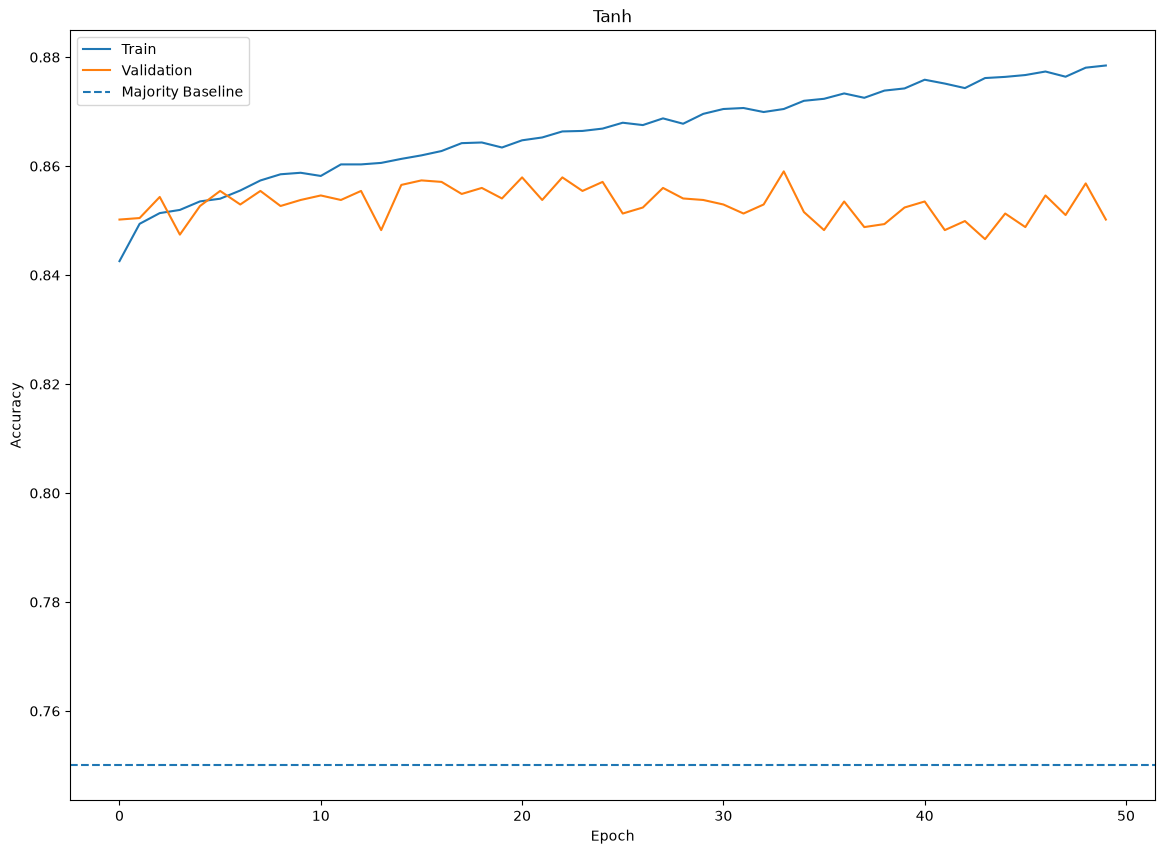

In [50]:
plt.figure(figsize=(14, 10))
plt.plot(
    history_tanh.history["accuracy"],
    label="Train"
)

plt.plot(
    history_tanh.history["val_accuracy"],
    label="Validation"
)

plt.title("Tanh")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.axhline(
    y=0.75,
    linestyle="--",
    label="Majority Baseline"
)

plt.legend()
plt.show()

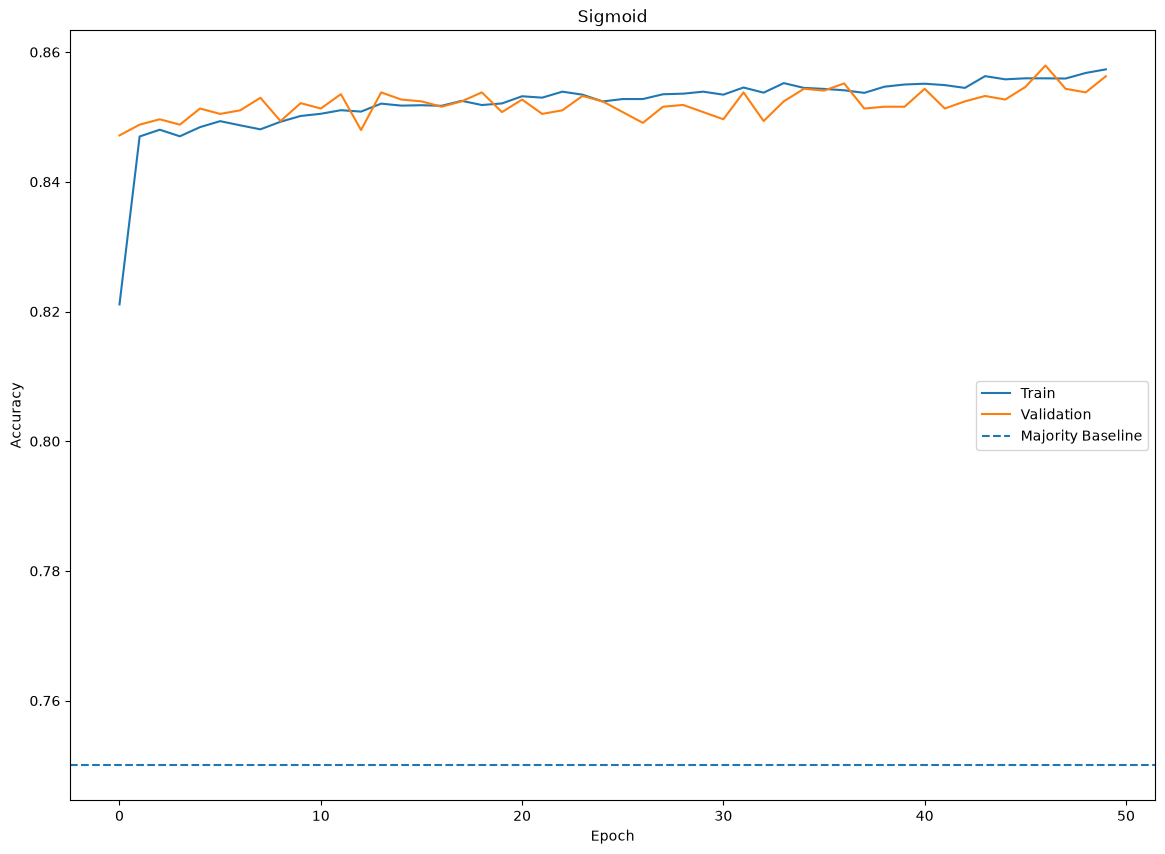

In [55]:
plt.figure(figsize=(14, 10))
plt.plot(
    history_sigmoid.history["accuracy"],
    label="Train"
)

plt.plot(
    history_sigmoid.history["val_accuracy"],
    label="Validation"
)

plt.title("Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.axhline(
    y=0.75,
    linestyle="--",
    label="Majority Baseline"
)

plt.legend()
plt.show()

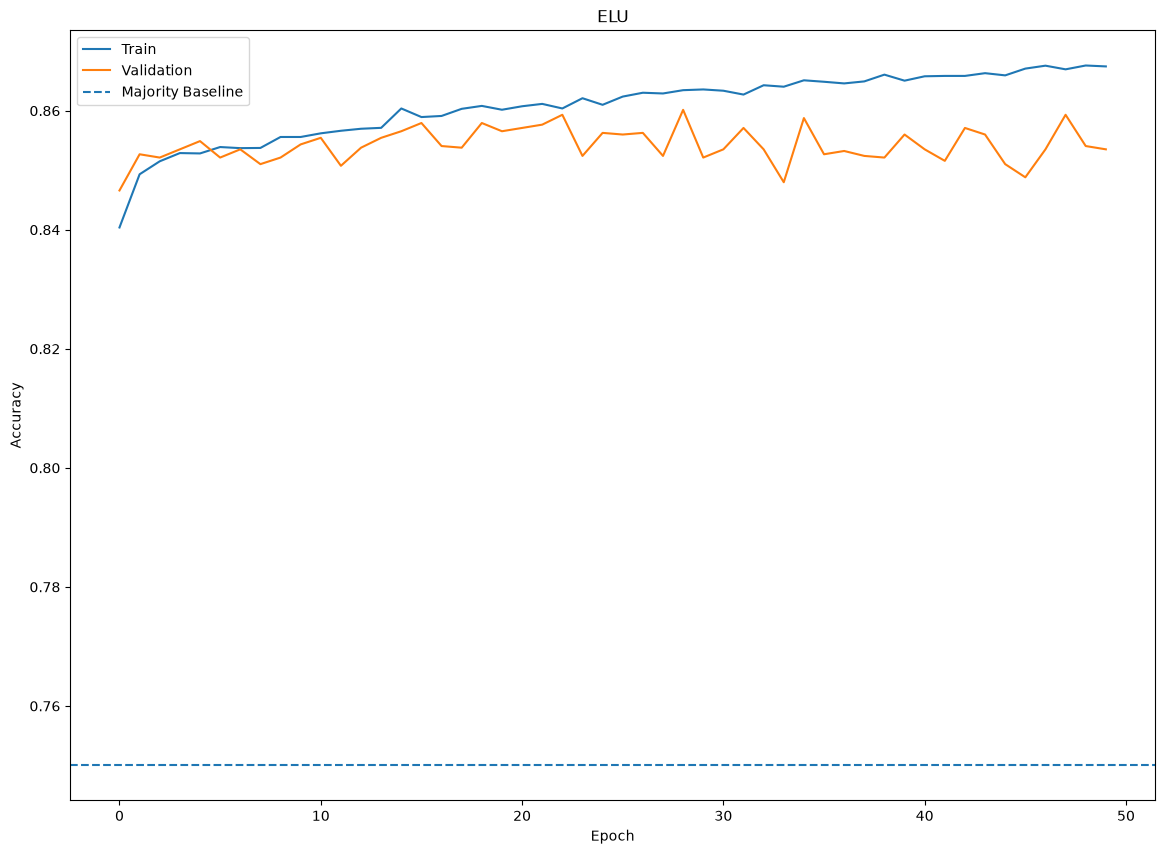

In [54]:
plt.figure(figsize=(14, 10))
plt.plot(
    history_elu.history["accuracy"],
    label="Train"
)

plt.plot(
    history_elu.history["val_accuracy"],
    label="Validation"
)

plt.title("ELU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.axhline(
    y=0.75,
    linestyle="--",
    label="Majority Baseline"
)

plt.legend()
plt.show()

## Activation Function Results

In [62]:
# Store models
activation_models = {
    "ReLU": model_relu,
    "Tanh": model_tanh,
    "Sigmoid": model_sigmoid,
    "ELU": model_elu
}

In [63]:
# Activation results
activation_results = []

for name, model in activation_models.items():
    prob = model.predict(X_test, verbose=0).flatten()
    pred = (prob >= 0.5).astype(int)

    activation_results.append({
        "Activation": name,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "PR-AUC": average_precision_score(y_test, prob)
    })

activation_results = pd.DataFrame(activation_results)
display(activation_results)

,Activation,Test Accuracy,Precision,Recall,F1,PR-AUC
0,ReLU,0.842786,0.706862,0.624888,0.663352,0.741178
1,Tanh,0.850083,0.741285,0.607047,0.667484,0.778859
2,Sigmoid,0.853510,0.727996,0.652988,0.688455,0.786991
3,ELU,0.849972,0.722250,0.641392,0.679424,0.778410


## 3.3: ReLU Dead Neuron Check

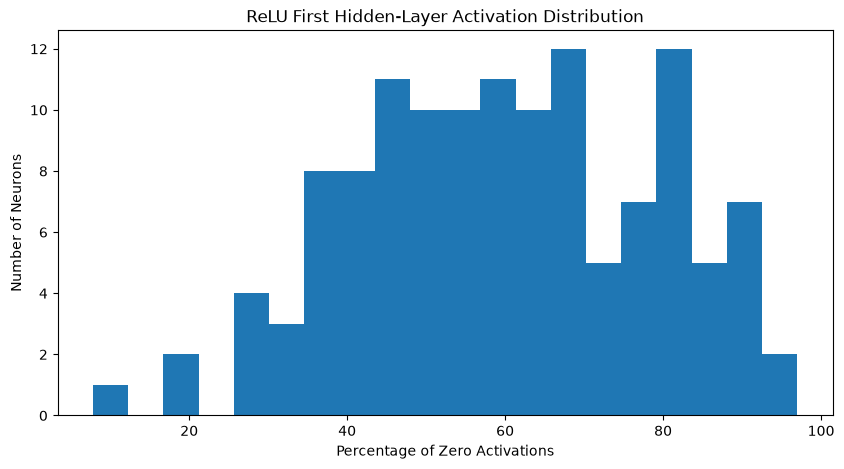

Average zero activation percentage: 59.8640625


In [70]:
# Get the first hidden layer from the ReLU model
relu_layer = activation_models["ReLU"].layers[0]

# Get output of the first hidden layer for 500 test samples
relu_activation = relu_layer(
    X_test.iloc[:500].values,
    training=False
).numpy()

# Calculate percentage of zero activations for each neuron
dead_neurons = np.mean(relu_activation == 0, axis=0) * 100

# Plot distribution
plt.figure(figsize=(10, 5))

plt.hist(
    dead_neurons,
    bins=20
)

plt.xlabel("Percentage of Zero Activations")
plt.ylabel("Number of Neurons")
plt.title("ReLU First Hidden-Layer Activation Distribution")

plt.show()

# Print average percentage
print("Average zero activation percentage:",dead_neurons.mean())

## 3.4 Gradient Flow Check for Sigmoid

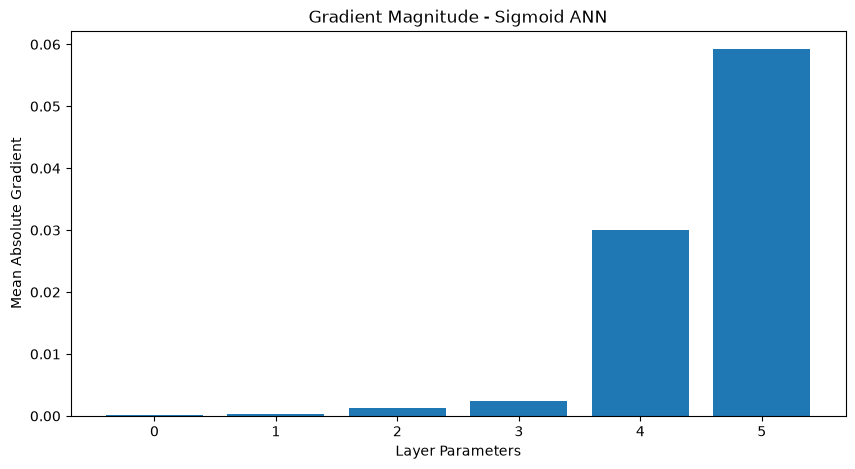

In [71]:
# Build sigmoid model
gradient_model = build_ann(
    X_train.shape[1],
    activation="sigmoid"
)

# Select small batch
x_sample = tf.convert_to_tensor(
    X_train.iloc[:128].values,
    dtype=tf.float32
)

y_sample = tf.convert_to_tensor(
    y_train.iloc[:128].values.reshape(-1, 1),
    dtype=tf.float32
)

# Gradient calculation
with tf.GradientTape() as tape:

    # Make prediction
    prediction = gradient_model(x_sample)

    # Calculate loss
    loss_value = tf.keras.losses.binary_crossentropy(
        y_sample,
        prediction
    )
    loss_value = tf.reduce_mean(loss_value)

# Calculate gradients
gradients = tape.gradient(
    loss_value,
    gradient_model.trainable_variables
)

# Calculate gradient magnitude
gradient_values = []

for gradient in gradients:

    gradient_values.append(
        tf.reduce_mean(
            tf.abs(gradient)
        ).numpy()
    )

# Plot gradients
plt.figure(figsize=(10, 5))
plt.bar(range(len(gradient_values)),gradient_values)
plt.xlabel("Layer Parameters")
plt.ylabel("Mean Absolute Gradient")
plt.title("Gradient Magnitude - Sigmoid ANN")
plt.show()

## 3.5 Activation Summary Table

In [72]:
# Create activation summary
activation_summary = pd.DataFrame({
    "Activation": [
        "ReLU",
        "Tanh",
        "Sigmoid",
        "ELU"
    ],
    "Formula": [
        "max(0, x)",
        "tanh(x)",
        "1 / (1 + e^-x)",
        "x if x>0 else alpha*(e^x-1)"
    ],
    "Main Advantage": [
        "Fast and avoids strong saturation for positive inputs",
        "Zero-centered output",
        "Smooth probability-like output",
        "Reduces dead neuron problem"
    ],
    "Main Problem": [
        "Dead neurons",
        "Can saturate",
        "Vanishing gradients",
        "Slightly more computationally expensive"
    ]
})

display(activation_summary)

,Activation,Formula,Main Advantage,Main Problem
0,ReLU,"max(0, x)",Fast and avoids strong saturation for positive...,Dead neurons
1,Tanh,tanh(x),Zero-centered output,Can saturate
2,Sigmoid,1 / (1 + e^-x),Smooth probability-like output,Vanishing gradients
3,ELU,x if x>0 else alpha*(e^x-1),Reduces dead neuron problem,Slightly more computationally expensive


# 4: WEIGHT INITIALIZATION

We compare:

* zeros
* random_normal
* glorot_uniform
* he_normal
* he_uniform
## 4.1 Train Five Models

In [73]:
# Create initializer dictionary
initializers = {
    "zeros": "zeros",
    "random_normal": "random_normal",
    "glorot_uniform": "glorot_uniform",
    "he_normal": "he_normal",
    "he_uniform": "he_uniform"
}

initializer_models = {}
initializer_histories = {}

# Train each initializer
for name, initializer in initializers.items():

    # Build model
    model = build_ann(
        input_dim=X_train.shape[1],
        activation="relu",
        initializer=initializer
    )

    # Train model
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.10,
        verbose=0
    )

    # Store model
    initializer_models[name] = model
    initializer_histories[name] = history
    print(name, "completed")

zeros completed
random_normal completed
glorot_uniform completed
he_normal completed
he_uniform completed


## 4.2 Convergence Speed Plot

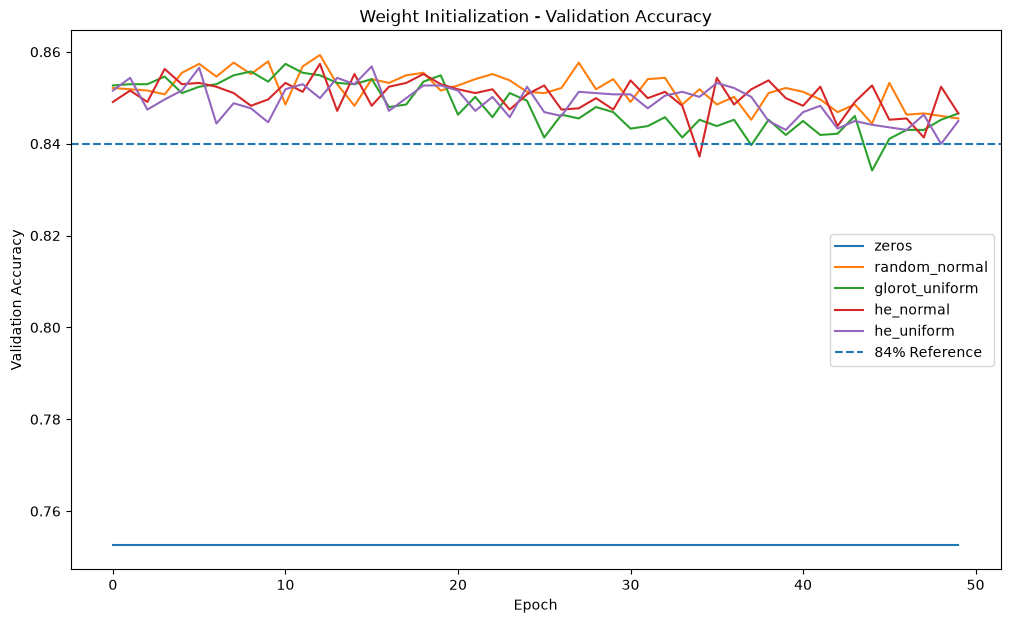

In [74]:
# Create plot
plt.figure(figsize=(12, 7))

# Plot every initializer
for name, history in initializer_histories.items():

    plt.plot(
        history.history["val_accuracy"],label=name)

# Add 84% reference line
plt.axhline(
    y=0.84,
    linestyle="--",
    label="84% Reference"
)

plt.title("Weight Initialization - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## 4.3 Initialization Results

In [75]:
# Create empty list
initializer_results = []

# Evaluate each model
for name, model in initializer_models.items():

    # Predict probabilities
    prob = model.predict(
        X_test,
        verbose=0
    ).flatten()

    # Convert probabilities to class
    pred = (prob >= 0.5).astype(int)

    # Store results
    initializer_results.append({
        "Initializer": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "PR-AUC": average_precision_score(y_test, prob)
    })

# Convert to DataFrame
initializer_results = pd.DataFrame(
    initializer_results
)

display(initializer_results)

C:\Users\Santosh verma\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Initializer,Accuracy,Precision,Recall,F1,PR-AUC
0,zeros,0.752128,0.000000,0.000000,0.000000,0.247872
1,random_normal,0.841902,0.699607,0.634701,0.665575,0.750179
2,glorot_uniform,0.842897,0.707219,0.624888,0.663509,0.744537
3,he_normal,0.835600,0.680536,0.634701,0.656820,0.732410
4,he_uniform,0.834936,0.704087,0.576271,0.633799,0.738636


## 4.4 Zero Initialization Failure

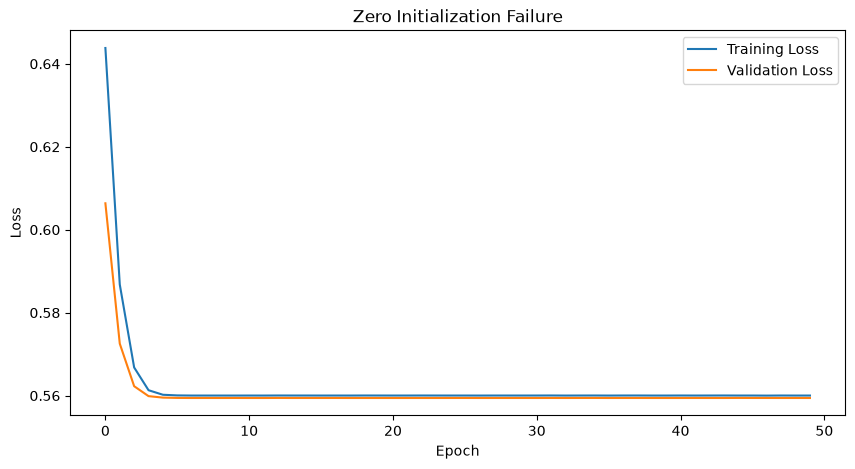

In [76]:
# Get zero initializer history
zero_history = initializer_histories["zeros"]
plt.figure(figsize=(10, 5))

plt.plot(
    zero_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    zero_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Zero Initialization Failure")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 4.5 Weight Distribution

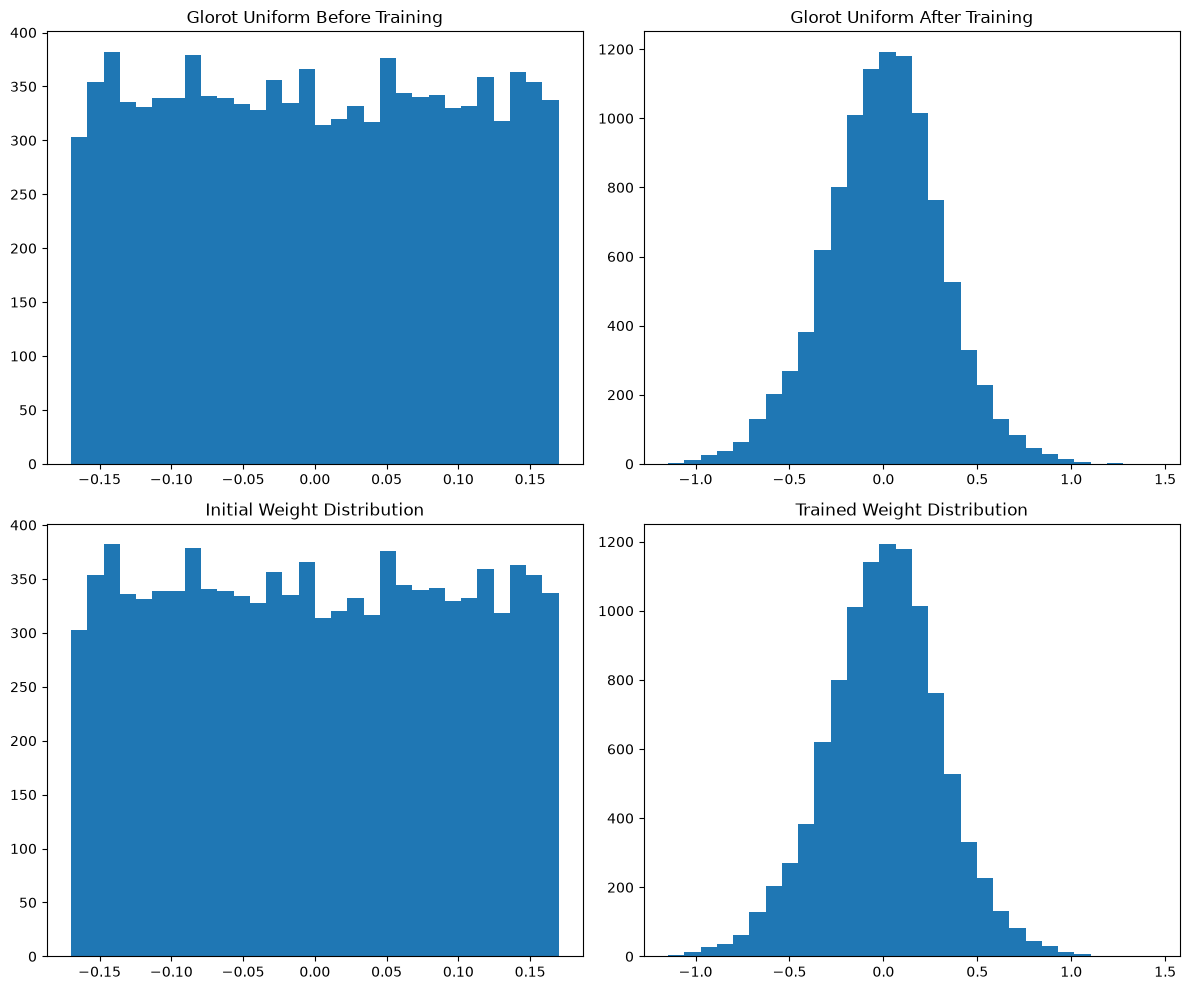

In [77]:
# Build model before training
weight_model_before = build_ann(
    X_train.shape[1],
    activation="relu",
    initializer="glorot_uniform"
)

# Extract first Dense layer weights
weights_before = weight_model_before.layers[0].get_weights()[0]

# Train model
weight_model_before.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=0
)

# Extract weights after training
weights_after = weight_model_before.layers[0].get_weights()[0]

# Create 2x2 plot
plt.figure(figsize=(12, 10))

# Normal before
plt.subplot(2, 2, 1)
plt.hist(weights_before.flatten(),bins=30)
plt.title("Glorot Uniform Before Training")


# Normal after
plt.subplot(2, 2, 2)
plt.hist(weights_after.flatten(),bins=30)
plt.title("Glorot Uniform After Training")


# Weight statistics
plt.subplot(2, 2, 3)
plt.hist(weights_before.flatten(),bins=30)
plt.title("Initial Weight Distribution")


# Trained statistics
plt.subplot(2, 2, 4)
plt.hist(weights_after.flatten(),bins=30)
plt.title("Trained Weight Distribution")
plt.tight_layout()
plt.show()

# 5: LOSS FUNCTIONS

We compare:

* Binary Cross Entropy
* MSE
* Weighted Binary Cross Entropy
* Focal Loss
## 5.1 Binary Cross Entropy

In [78]:
# Display BCE formula
print(
    "Binary Cross Entropy = -[y*log(p) + (1-y)*log(1-p)]"
)

print(
    "BCE is suitable for binary classification."
)

Binary Cross Entropy = -[y*log(p) + (1-y)*log(1-p)]
BCE is suitable for binary classification.


## 5.2 MSE as Classification Loss

In [81]:
# Build MSE model
model_mse = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    loss="mean_squared_error"
)

# Train MSE model
history_mse = model_mse.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8444 - loss: 0.1073 - val_accuracy: 0.8532 - val_loss: 0.1026
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8535 - loss: 0.1006 - val_accuracy: 0.8458 - val_loss: 0.1029
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8563 - loss: 0.0991 - val_accuracy: 0.8538 - val_loss: 0.1025
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8585 - loss: 0.0978 - val_accuracy: 0.8538 - val_loss: 0.1035
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8598 - loss: 0.0970 - val_accuracy: 0.8563 - val_loss: 0.1010
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8615 - loss: 0.0959 - val_accuracy: 0.8549 - val_loss: 0.1024
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8626 - loss: 0.0949 - val_accuracy: 0.8582 - val_loss: 0.1012
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8655 - loss: 0.0941 - val_accuracy: 0.

In [82]:
# Predict MSE model
mse_prob = model_mse.predict(X_test,verbose=0).flatten()
mse_pred = (mse_prob >= 0.5).astype(int)

# Print metrics
print("MSE Model")
print("Accuracy :", accuracy_score(y_test, mse_pred))
print("Precision:", precision_score(y_test, mse_pred))
print("Recall   :", recall_score(y_test, mse_pred))
print("F1       :", f1_score(y_test, mse_pred))
print("PR-AUC   :", average_precision_score(y_test, mse_prob))

MSE Model
Accuracy : 0.838253178551686
Precision: 0.676483914816493
Recall   : 0.6659232827832292
F1       : 0.6711620588896381
PR-AUC   : 0.7500570790405581


## 5.3 Weighted Binary Cross Entropy

In [83]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Convert class weights into dictionary
class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

# Display weights
print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(0.6647495498144133), 1: np.float64(2.0174548293553425)}


In [85]:
# Build weighted BCE model
model_wbce = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    loss="binary_crossentropy"
)

# Train with class weights
history_wbce = model_wbce.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7983 - loss: 0.3962 - val_accuracy: 0.7922 - val_loss: 0.4123
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8085 - loss: 0.3721 - val_accuracy: 0.8013 - val_loss: 0.3867
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8119 - loss: 0.3675 - val_accuracy: 0.7872 - val_loss: 0.4263
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8127 - loss: 0.3638 - val_accuracy: 0.8065 - val_loss: 0.3794
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8140 - loss: 0.3601 - val_accuracy: 0.8179 - val_loss: 0.3726
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8181 - loss: 0.3568 - val_accuracy: 0.8129 - val_loss: 0.3766
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8188 - loss: 0.3536 - val_accuracy: 0.8234 - val_loss: 0.3583
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8207 - loss: 0.3502 - val_accuracy: 0.

In [86]:
wbce_prob = model_wbce.predict(X_test,verbose=0).flatten()
wbce_pred = (wbce_prob >= 0.5).astype(int)

# Print metrics
print("Weighted BCE")
print("Accuracy :", accuracy_score(y_test, wbce_pred))
print("Precision:", precision_score(y_test, wbce_pred))
print("Recall   :", recall_score(y_test, wbce_pred))
print("F1       :", f1_score(y_test, wbce_pred))
print("PR-AUC   :", average_precision_score(y_test, wbce_prob))

Weighted BCE
Accuracy : 0.807739082365948
Precision: 0.5823240589198037
Recall   : 0.7934879571810883
F1       : 0.6717009628091373
PR-AUC   : 0.7436067750914176


## 5.4 Focal Loss

In [87]:
# Create focal loss function
def focal_loss(
    gamma=2.0,
    alpha=0.25
):

    # Create loss function
    def loss_function(y_true, y_pred):

        # Convert labels to float
        y_true = tf.cast(
            y_true,
            tf.float32
        )

        # Clip predictions
        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1 - 1e-7
        )

        # Binary cross entropy
        bce = -(
            y_true * tf.math.log(y_pred)
            +
            (1 - y_true) * tf.math.log(1 - y_pred)
        )

        # Calculate p_t
        p_t = (
            y_true * y_pred
            +
            (1 - y_true) * (1 - y_pred)
        )

        # Calculate alpha
        alpha_factor = (
            y_true * alpha
            +
            (1 - y_true) * (1 - alpha)
        )

        # Calculate focal weight
        focal_weight = alpha_factor * tf.pow(
            1 - p_t,
            gamma
        )

        # Calculate focal loss
        loss = focal_weight * bce

        # Return mean loss
        return tf.reduce_mean(loss)

    # Return loss
    return loss_function

In [88]:
# Build focal loss model
model_focal = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    loss=focal_loss(
        gamma=2.0,
        alpha=0.25
    )
)

# Train focal model
history_focal = model_focal.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8109 - loss: 0.0362 - val_accuracy: 0.8261 - val_loss: 0.0336
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8282 - loss: 0.0328 - val_accuracy: 0.8170 - val_loss: 0.0337
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8307 - loss: 0.0323 - val_accuracy: 0.8179 - val_loss: 0.0334
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8323 - loss: 0.0318 - val_accuracy: 0.8322 - val_loss: 0.0335
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8341 - loss: 0.0316 - val_accuracy: 0.8325 - val_loss: 0.0336
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8353 - loss: 0.0312 - val_accuracy: 0.8192 - val_loss: 0.0329
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8364 - loss: 0.0309 - val_accuracy: 0.8167 - val_loss: 0.0330
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8384 - loss: 0.0307 - val_accuracy: 0.

In [89]:
focal_prob = model_focal.predict(X_test,verbose=0).flatten()
focal_pred = (focal_prob >= 0.5).astype(int)

# Display metrics
print("Focal Loss")
print("Accuracy :", accuracy_score(y_test, focal_pred))
print("Precision:", precision_score(y_test, focal_pred))
print("Recall   :", recall_score(y_test, focal_pred))
print("F1       :", f1_score(y_test, focal_pred))
print("PR-AUC   :", average_precision_score(y_test, focal_prob))

Focal Loss
Accuracy : 0.8349364289662797
Precision: 0.7650389242745931
Recall   : 0.48215878679750224
F1       : 0.5915184678522571
PR-AUC   : 0.7366534906906462


## 5.5 Loss Function Summary

In [90]:
# Create loss summary table
loss_summary = pd.DataFrame({
    "Loss Function": [
        "Binary Cross Entropy",
        "MSE",
        "Weighted BCE",
        "Focal Loss"
    ],
    "Best For": [
        "Binary Classification",
        "Regression / simple classification comparison",
        "Imbalanced Classification",
        "Strong Class Imbalance"
    ],
    "Main Advantage": [
        "Correct probabilistic classification loss",
        "Simple and easy",
        "Gives more importance to minority class",
        "Focuses on hard examples"
    ]
})

# Display table
display(loss_summary)

,Loss Function,Best For,Main Advantage
0,Binary Cross Entropy,Binary Classification,Correct probabilistic classification loss
1,MSE,Regression / simple classification comparison,Simple and easy
2,Weighted BCE,Imbalanced Classification,Gives more importance to minority class
3,Focal Loss,Strong Class Imbalance,Focuses on hard examples


## Compare Loss Functions

In [91]:
loss_results = pd.DataFrame({
    "Loss": [
        "BCE",
        "MSE",
        "Weighted BCE",
        "Focal Loss"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, mse_pred),
        accuracy_score(y_test, wbce_pred),
        accuracy_score(y_test, focal_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, mse_pred),
        precision_score(y_test, wbce_pred),
        precision_score(y_test, focal_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, mse_pred),
        recall_score(y_test, wbce_pred),
        recall_score(y_test, focal_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, mse_pred),
        f1_score(y_test, wbce_pred),
        f1_score(y_test, focal_pred)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_pred_prob),
        average_precision_score(y_test, mse_prob),
        average_precision_score(y_test, wbce_prob),
        average_precision_score(y_test, focal_prob)
    ]
})

display(loss_results)

,Loss,Accuracy,Precision,Recall,F1,PR-AUC
0,BCE,0.839912,0.697709,0.624888,0.659294,0.745742
1,MSE,0.838253,0.676484,0.665923,0.671162,0.750057
2,Weighted BCE,0.807739,0.582324,0.793488,0.671701,0.743607
3,Focal Loss,0.834936,0.765039,0.482159,0.591518,0.736653


# 6: BATCH NORMALIZATION
## 6.1 ANN with Batch Normalization

In [92]:
model_bn = keras.Sequential([
    
    keras.layers.Input(
        shape=(X_train.shape[1],)
    ),

    keras.layers.Dense(
        128,
        kernel_initializer="he_normal"
    ),

    keras.layers.BatchNormalization(),

    # Activation
    keras.layers.Activation("relu"),

    # Second Dense layer
    keras.layers.Dense(
        64,
        kernel_initializer="he_normal"
    ),

    keras.layers.BatchNormalization(),

    keras.layers.Activation("relu"),

    # Output layer
    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

# Compile model
model_bn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_bn.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

## 6.2 Train BatchNorm Model

In [93]:
history_bn = model_bn.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8383 - loss: 0.3436 - val_accuracy: 0.8485 - val_loss: 0.3271
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8493 - loss: 0.3197 - val_accuracy: 0.8483 - val_loss: 0.3251
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8529 - loss: 0.3150 - val_accuracy: 0.8499 - val_loss: 0.3238
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8558 - loss: 0.3101 - val_accuracy: 0.8513 - val_loss: 0.3217
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8562 - loss: 0.3072 - val_accuracy: 0.8524 - val_loss: 0.3236
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8573 - loss: 0.3057 - val_accuracy: 0.8499 - val_loss: 0.3216
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8599 - loss: 0.3025 - val_accuracy: 0.8535 - val_loss: 0.3214
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8603 - loss: 0.3011 - val_accuracy: 0.

## Compare With Baseline

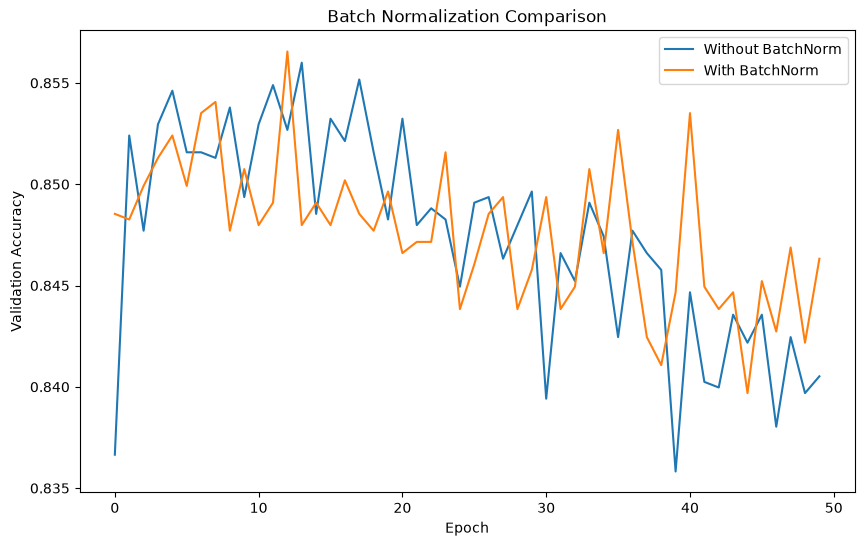

In [94]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_base.history["val_accuracy"],
    label="Without BatchNorm"
)

plt.plot(
    history_bn.history["val_accuracy"],
    label="With BatchNorm"
)

plt.title("Batch Normalization Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## Evaluate BatchNorm

In [ ]:
bn_prob = model_bn.predict(X_test,verbose=0).flatten()

bn_pred = (bn_prob >= 0.5).astype(int)

# Calculate metrics
print("Batch Normalization Model")
print(
    "Accuracy :",accuracy_score(y_test, bn_pred))
print(
    "Precision:",precision_score(y_test, bn_pred))
print(
    "Recall   :",recall_score(y_test, bn_pred))
print(
    "F1       :",f1_score(y_test, bn_pred))
print(
    "PR-AUC   :",average_precision_score(y_test, bn_prob))

Batch Normalization Model
Accuracy : 0.8413488114980652
Precision: 0.7098283931357254
Recall   : 0.6088314005352364
F1       : 0.6554621848739496
PR-AUC   : 0.7547753183155596


## 6.4 BatchNorm Position Experiment

In [96]:
# Model where BatchNorm comes after activation
model_bn_after = keras.Sequential([

    keras.layers.Input(
        shape=(X_train.shape[1],)
    ),

    keras.layers.Dense(
        128,
        kernel_initializer="he_normal"
    ),

    keras.layers.Activation("relu"),

    keras.layers.BatchNormalization(),

    keras.layers.Dense(
        64,
        kernel_initializer="he_normal"
    ),

    keras.layers.Activation("relu"),

    keras.layers.BatchNormalization(),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [97]:

model_bn_after.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train
history_bn_after = model_bn_after.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.10,
    verbose=0
)

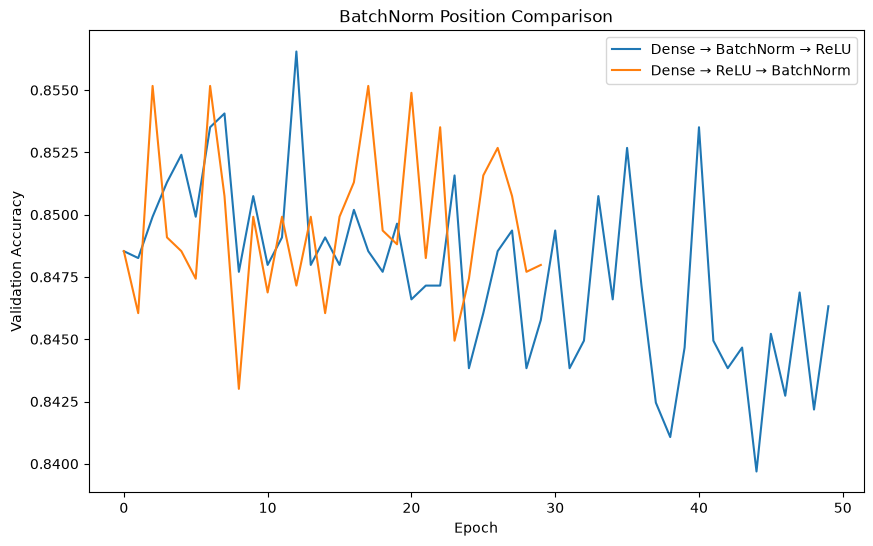

In [98]:
# Plot both versions
plt.figure(figsize=(10, 6))

plt.plot(
    history_bn.history["val_accuracy"],
    label="Dense → BatchNorm → ReLU"
)

plt.plot(
    history_bn_after.history["val_accuracy"],
    label="Dense → ReLU → BatchNorm"
)

plt.title("BatchNorm Position Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## 6.5 Inspect Gamma and Beta

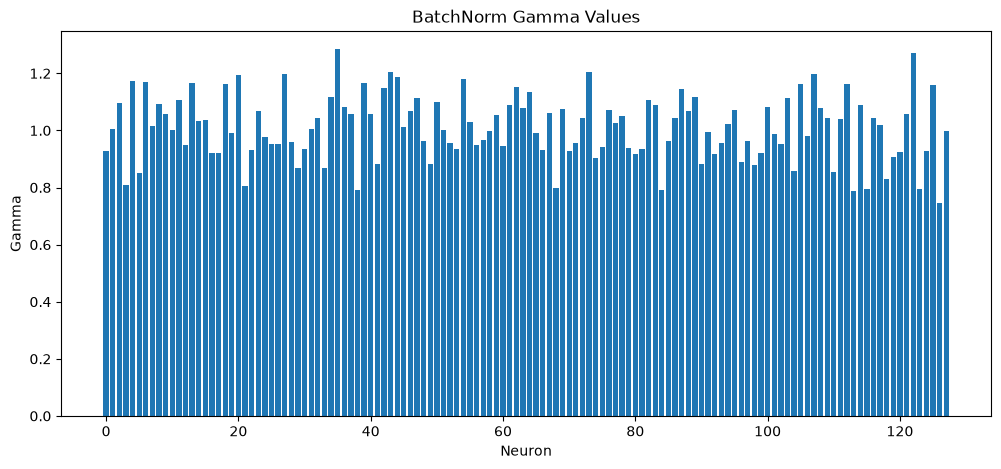

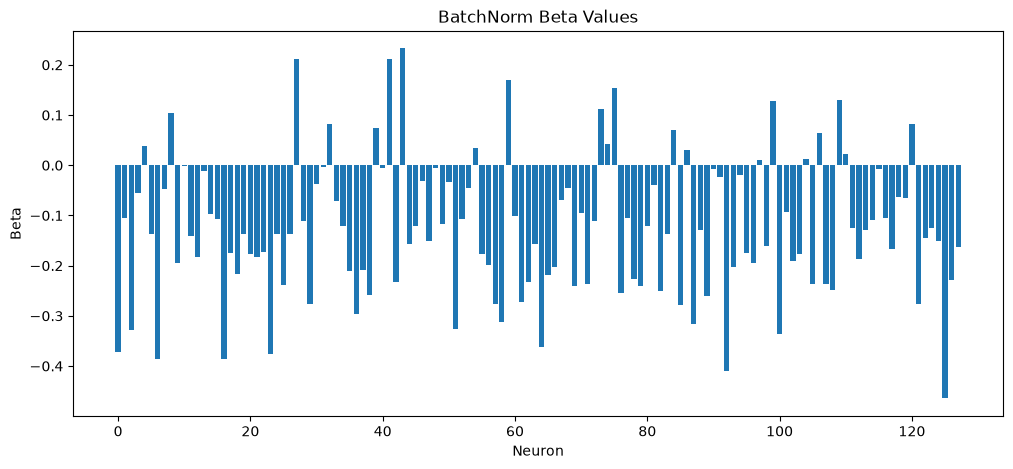

In [100]:
# Find BatchNorm layer
bn_layer = None

for layer in model_bn.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        bn_layer = layer
        break

# Get parameters
gamma = bn_layer.gamma.numpy()
beta = bn_layer.beta.numpy()

# Plot gamma
plt.figure(figsize=(12, 5))
plt.bar(range(len(gamma)), gamma)
plt.title("BatchNorm Gamma Values")
plt.xlabel("Neuron")
plt.ylabel("Gamma")
plt.show()

# Plot beta
plt.figure(figsize=(12, 5))
plt.bar(range(len(beta)), beta)
plt.title("BatchNorm Beta Values")
plt.xlabel("Neuron")
plt.ylabel("Beta")
plt.show()

# 7: OPTIMIZERS

We compare:

* SGD
* SGD + Momentum
* RMSProp
* Adam
* Adam Explicit
## 7.1 Train Five Optimizers

In [101]:
# Optimizer 1: Vanilla SGD
optimizer_sgd = keras.optimizers.SGD(
    learning_rate=0.01
)

# Build model
model_sgd = build_ann(
    X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    optimizer=optimizer_sgd
)

# Train
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=0
)

In [102]:
# Optimizer 2: SGD Momentum
optimizer_momentum = keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

# Build model
model_momentum = build_ann(
    X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    optimizer=optimizer_momentum
)

# Train
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=0
)

In [103]:
# Optimizer 3: RMSProp
optimizer_rmsprop = keras.optimizers.RMSprop(
    learning_rate=0.001,
    rho=0.9
)

# Build model
model_rmsprop = build_ann(
    X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    optimizer=optimizer_rmsprop
)

# Train
history_rmsprop = model_rmsprop.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=0
)

In [104]:
# Optimizer 4: Adam
optimizer_adam = keras.optimizers.Adam(
    learning_rate=0.001
)

# Build model
model_adam = build_ann(
    X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    optimizer=optimizer_adam
)

# Train
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=0
)


# Optimizer 5: Explicit Adam
optimizer_adam_explicit = keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999
)
# Build model
model_adam_explicit = build_ann(
    X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    optimizer=optimizer_adam_explicit
)

# Train
history_adam_explicit = model_adam_explicit.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.10,
    verbose=0
)

## 7.2 Optimizer Convergence Plot

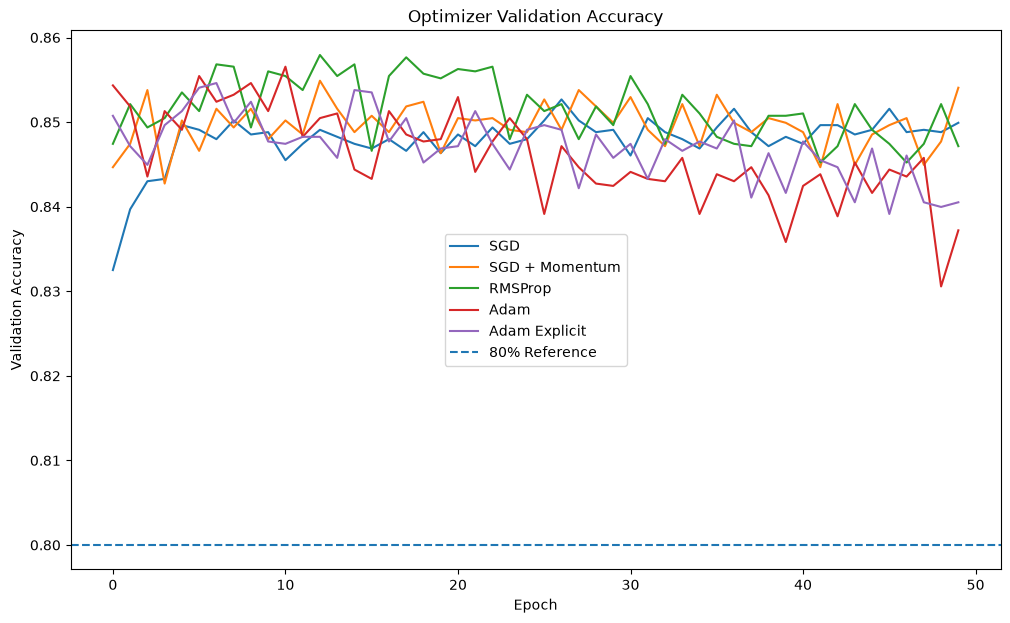

In [105]:
# Create figure
plt.figure(figsize=(12, 7))

# Plot SGD
plt.plot(history_sgd.history["val_accuracy"],label="SGD")

# Plot Momentum
plt.plot(history_momentum.history["val_accuracy"],label="SGD + Momentum")

# Plot RMSProp
plt.plot(history_rmsprop.history["val_accuracy"],label="RMSProp")

# Plot Adam
plt.plot(history_adam.history["val_accuracy"],label="Adam")

# Plot explicit Adam
plt.plot(history_adam_explicit.history["val_accuracy"],label="Adam Explicit")

# 80% reference
plt.axhline(
    y=0.80,
    linestyle="--",
    label="80% Reference"
)
plt.title("Optimizer Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## Optimizer Results

In [106]:
# Store optimizer models
optimizer_models = {
    "SGD": model_sgd,
    "SGD + Momentum": model_momentum,
    "RMSProp": model_rmsprop,
    "Adam": model_adam,
    "Adam Explicit": model_adam_explicit
}
optimizer_results = []

for name, model in optimizer_models.items():

    prob = model.predict(
        X_test,
        verbose=0
    ).flatten()

    # Convert to class
    pred = (prob >= 0.5).astype(int)

    # Add results
    optimizer_results.append({
        "Optimizer": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "PR-AUC": average_precision_score(
            y_test,
            prob
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            prob
        )
    })

# Convert to DataFrame
optimizer_results = pd.DataFrame(
    optimizer_results
)
display(optimizer_results)

,Optimizer,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
0,SGD,0.850857,0.724485,0.642730,0.681163,0.779467,0.909501
1,SGD + Momentum,0.849420,0.705224,0.674398,0.689466,0.779808,0.907675
2,RMSProp,0.842123,0.688601,0.662801,0.675455,0.763375,0.897080
3,Adam,0.836263,0.673191,0.659679,0.666366,0.746132,0.889638
4,Adam Explicit,0.837590,0.694710,0.615076,0.652472,0.738776,0.885606


# 7.3 Why Adam Performs Well

Vanilla SGD uses one global learning rate and can converge slowly.

SGD with Momentum adds previous update information and reduces oscillation.

RMSProp adapts the learning rate using a moving average of squared gradients.

Adam combines momentum-like first-moment estimation with second-moment estimation. Therefore, it can adapt the learning rate separately for different parameters.

For a high-dimensional tabular dataset such as Adult Income, Adam usually provides fast and stable convergence with minimal manual tuning.

## 7.4 Learning Rate Sensitivity

## SGD

In [107]:
# SGD learning rates
sgd_learning_rates = [0.001,0.01,0.1]
sgd_lr_histories = {}

# Train models
for lr in sgd_learning_rates:

    # Create optimizer
    optimizer = keras.optimizers.SGD(
        learning_rate=lr
    )

    # Build model
    model = build_ann(
        X_train.shape[1],
        activation="relu",
        initializer="he_normal",
        optimizer=optimizer
    )

    # Train
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.10,
        verbose=0
    )

    # Store history
    sgd_lr_histories[lr] = history

## Adam

In [108]:
# Adam learning rates
adam_learning_rates = [0.0001,0.001,0.01]
adam_lr_histories = {}

# Train models
for lr in adam_learning_rates:

    # Create optimizer
    optimizer = keras.optimizers.Adam(
        learning_rate=lr
    )

    # Build model
    model = build_ann(
        X_train.shape[1],
        activation="relu",
        initializer="he_normal",
        optimizer=optimizer
    )

    # Train
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.10,
        verbose=0
    )
    adam_lr_histories[lr] = history

## Learning Rate Plot

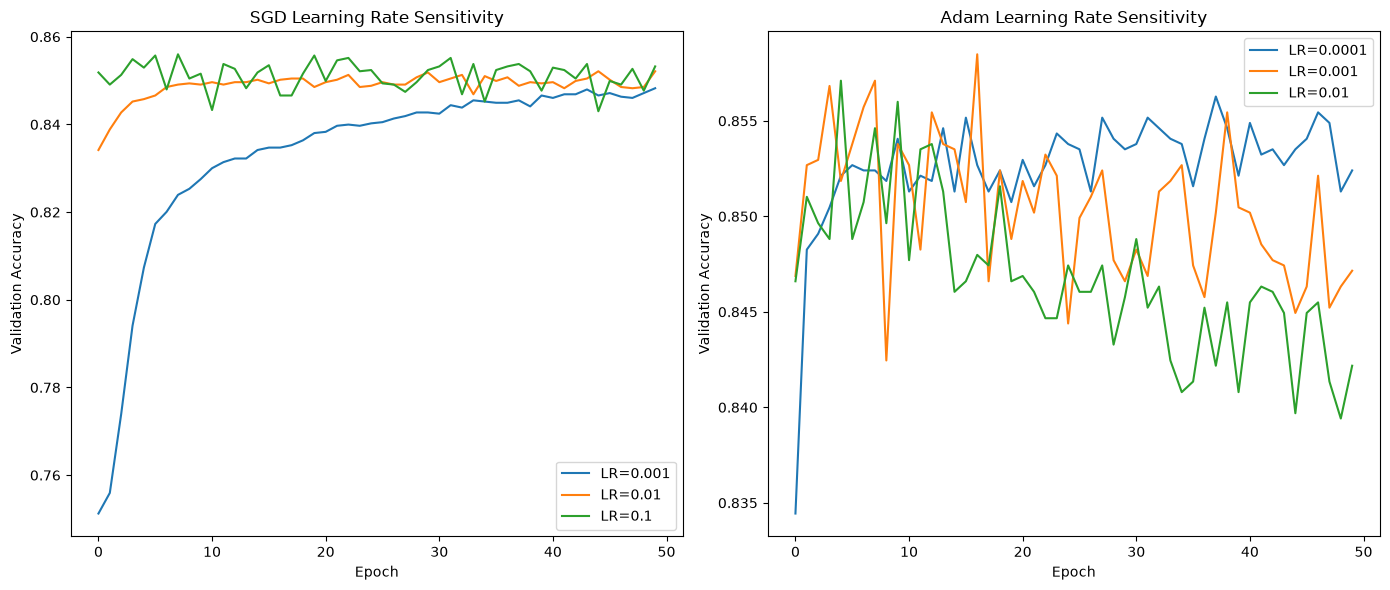

In [109]:
# Create figure
plt.figure(figsize=(14, 6))

# SGD plot
plt.subplot(1, 2, 1)

for lr, history in sgd_lr_histories.items():

    plt.plot(
        history.history["val_accuracy"],
        label=f"LR={lr}"
    )

plt.title("SGD Learning Rate Sensitivity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()


# Adam plot
plt.subplot(1, 2, 2)

for lr, history in adam_lr_histories.items():

    plt.plot(
        history.history["val_accuracy"],
        label=f"LR={lr}"
    )

plt.title("Adam Learning Rate Sensitivity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 7.5 Final Combined ANN

For the final model, a strong configuration based on the experiments is:

* ReLU
* He Normal initialization
* Batch Normalization
* Adam
* Weighted Binary Cross Entropy
* 128 → 64 → 1
* Batch size = 64

In [110]:
# Create final ANN
final_model = keras.Sequential([

    # Input
    keras.layers.Input(
        shape=(X_train.shape[1],)
    ),

    # First Dense layer
    keras.layers.Dense(
        128,
        kernel_initializer="he_normal"
    ),

    # Batch Normalization
    keras.layers.BatchNormalization(),

    # ReLU activation
    keras.layers.Activation("relu"),

    # Second Dense layer
    keras.layers.Dense(
        64,
        kernel_initializer="he_normal"
    ),

    # Batch Normalization
    keras.layers.BatchNormalization(),

    # ReLU activation
    keras.layers.Activation("relu"),

    # Output
    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

# Compile final model
final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display architecture
final_model.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

## Train Final Model

In [111]:
# Train final model
final_history = final_model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.10,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7878 - loss: 0.4058 - val_accuracy: 0.8043 - val_loss: 0.3989
Epoch 2/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8082 - loss: 0.3760 - val_accuracy: 0.8126 - val_loss: 0.3754
Epoch 3/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8099 - loss: 0.3728 - val_accuracy: 0.8068 - val_loss: 0.3856
Epoch 4/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8121 - loss: 0.3664 - val_accuracy: 0.8024 - val_loss: 0.3913
Epoch 5/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8126 - loss: 0.3653 - val_accuracy: 0.8104 - val_loss: 0.3701
Epoch 6/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8150 - loss: 0.3609 - val_accuracy: 0.8162 - val_loss: 0.3659
Epoch 7/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8151 - loss: 0.3577 - val_accuracy: 0.8109 - val_loss: 0.3816
Epoch 8/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8185 - loss: 0.3534 - val_accuracy: 0.

In [112]:
# Predict probabilities
final_prob = final_model.predict(X_test,verbose=0).flatten()

# Convert probability into class
final_pred = (final_prob >= 0.5).astype(int)

# Calculate final metrics
final_accuracy = accuracy_score(y_test,final_pred)
final_precision = precision_score(y_test,final_pred)
final_recall = recall_score(y_test,final_pred)
final_f1 = f1_score(y_test,final_pred)
final_pr_auc = average_precision_score(y_test,final_prob)
final_roc_auc = roc_auc_score(y_test,final_prob)

# Print results
print("FINAL ANN RESULTS")
print("=================")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("PR-AUC   :", final_pr_auc)
print("ROC-AUC  :", final_roc_auc)

FINAL ANN RESULTS
Accuracy : 0.7995577667219458
Precision: 0.5663060278207109
Recall   : 0.8171275646743978
F1 Score : 0.6689793682672996
PR-AUC   : 0.7483131316692834
ROC-AUC  : 0.8926401782914948


## Final Classification Report

In [113]:
print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "<=50K",
            ">50K"
        ]
    )
)

              precision    recall  f1-score   support

       <=50K       0.93      0.79      0.86      6803
        >50K       0.57      0.82      0.67      2242

    accuracy                           0.80      9045
   macro avg       0.75      0.81      0.76      9045
weighted avg       0.84      0.80      0.81      9045



## Final Confusion Matrix

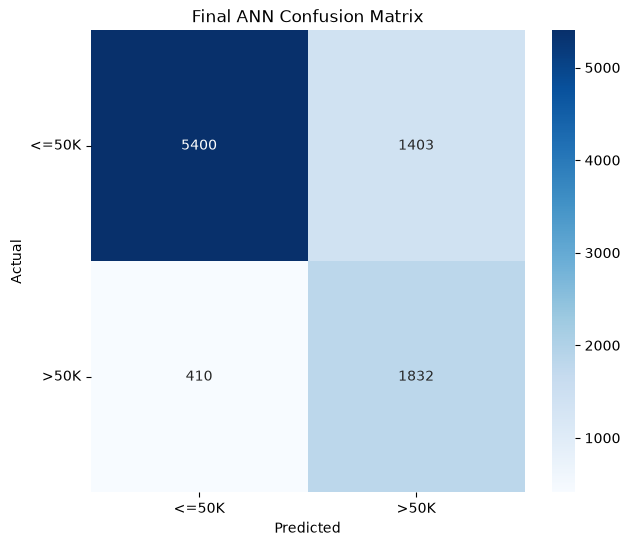

In [114]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(
    [0.5, 1.5],
    ["<=50K", ">50K"]
)

plt.yticks(
    [0.5, 1.5],
    ["<=50K", ">50K"],
    rotation=0
)
plt.show()

## Final Precision-Recall Curve

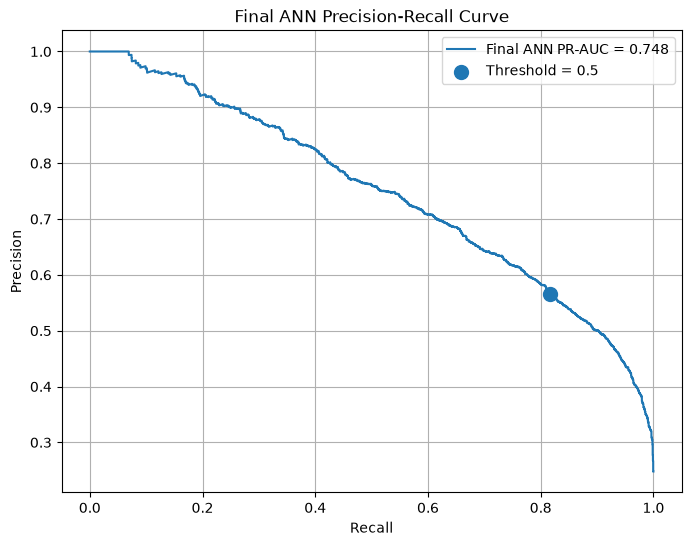

In [115]:
final_precision_curve, final_recall_curve, final_thresholds = (
    precision_recall_curve(
        y_test,
        final_prob
    )
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    final_recall_curve,
    final_precision_curve,
    label=f"Final ANN PR-AUC = {final_pr_auc:.3f}"
)

# Mark default threshold
default_index = np.argmin(
    np.abs(
        final_thresholds - 0.5
    )
)

plt.scatter(
    final_recall_curve[default_index],
    final_precision_curve[default_index],
    s=100,
    label="Threshold = 0.5"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final ANN Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

## 7.6 FULL RESULTS COMPARISON TABLE

In [116]:
# Create baseline result
baseline_result = {
    "Model": "Baseline ANN",
    "Activation": "ReLU",
    "Initializer": "Glorot Uniform",
    "Loss": "BCE",
    "BatchNorm": "No",
    "Optimizer": "Adam",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "PR-AUC": pr_auc,
    "ROC-AUC": roc_auc
}


# Create final result
final_result = {
    "Model": "Final ANN",
    "Activation": "ReLU",
    "Initializer": "He Normal",
    "Loss": "Weighted BCE",
    "BatchNorm": "Yes",
    "Optimizer": "Adam",
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "PR-AUC": final_pr_auc,
    "ROC-AUC": final_roc_auc
}


# Create DataFrame
final_results_table = pd.DataFrame([
    baseline_result,
    final_result
])

# Display
display(final_results_table)

,Model,Activation,Initializer,Loss,BatchNorm,Optimizer,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
0,Baseline ANN,ReLU,Glorot Uniform,BCE,No,Adam,0.839912,0.697709,0.624888,0.659294,0.745742,0.889349
1,Final ANN,ReLU,He Normal,Weighted BCE,Yes,Adam,0.799558,0.566306,0.817128,0.668979,0.748313,0.892640


## Save Final Model

In [117]:
# Save trained Keras model
final_model.save(
    "adult_income_ann.keras"
)
print("Final model saved successfully.")

Final model saved successfully.


In [118]:
# Import joblib
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)
print("Scaler saved successfully.")

Scaler saved successfully.


# Conclusion

The Adult Income dataset was used to build a binary classification model that predicts whether an individual's annual income is <=50K or >50K.

The dataset required preprocessing because it contained categorical features and missing values represented by '?'. Missing rows were removed, redundant columns were dropped, categorical features were one-hot encoded, and numerical features were standardized.

A baseline Multi-Layer Perceptron was created using two hidden layers containing 128 and 64 neurons. ReLU, Tanh, Sigmoid and ELU activation functions were compared. ReLU generally provides fast convergence and is suitable for hidden layers.

Different weight initialization methods were also compared. Zero initialization performs poorly because all neurons start with identical weights and learn identical features. Glorot and He initialization provide much better symmetry breaking and convergence.

Several loss functions were evaluated. Binary Cross Entropy is the standard loss for binary classification, while Weighted BCE and Focal Loss are useful when class imbalance needs special attention.

Batch Normalization was tested to improve training stability and convergence. Different BatchNorm positions were also compared.

Finally, SGD, SGD with Momentum, RMSProp and Adam optimizers were evaluated. Adam generally provides fast and stable convergence because it combines adaptive learning rates with momentum-based gradient information.

The final ANN combines ReLU activation, He Normal initialization, Batch Normalization, Adam optimization and class-weighted Binary Cross Entropy. Because the Adult Income dataset is imbalanced, F1-score, Recall and PR-AUC should be considered along with accuracy when selecting the final model.